**PROBLEM 1**

In [90]:

# Data from the table
total_players = 235

injured = {
    "Striker": 45,
    "Forward": 56,
    "Attacking Midfielder": 24,
    "Winger": 20
}

not_injured = {
    "Striker": 32,
    "Forward": 38,
    "Attacking Midfielder": 11,
    "Winger": 9
}

# Totals by position
totals = {
    "Striker": 77,
    "Forward": 94,
    "Attacking Midfielder": 35,
    "Winger": 29
}

total_injured = 145
total_not_injured = 90

# 1.1 Probability a randomly chosen player is injured
p_injured = total_injured / total_players

# 1.2 Probability player is a forward or a winger
p_forward_or_winger = (totals["Forward"] + totals["Winger"]) / total_players

# 1.3 Probability player is a striker AND injured
p_striker_and_injured = injured["Striker"] / total_players

# 1.4 Probability a randomly chosen injured player is a striker
p_striker_given_injured = injured["Striker"] / total_injured

# Print results
print("P(Injured) =", p_injured)
print("P(Forward or Winger) =", p_forward_or_winger)
print("P(Striker and Injured) =", p_striker_and_injured)
print("P(Striker | Injured) =", p_striker_given_injured)



P(Injured) = 0.6170212765957447
P(Forward or Winger) = 0.5234042553191489
P(Striker and Injured) = 0.19148936170212766
P(Striker | Injured) = 0.3103448275862069


**PROBLEM 2**

2.1 P(X < 3.17) = 0.11123243744783462


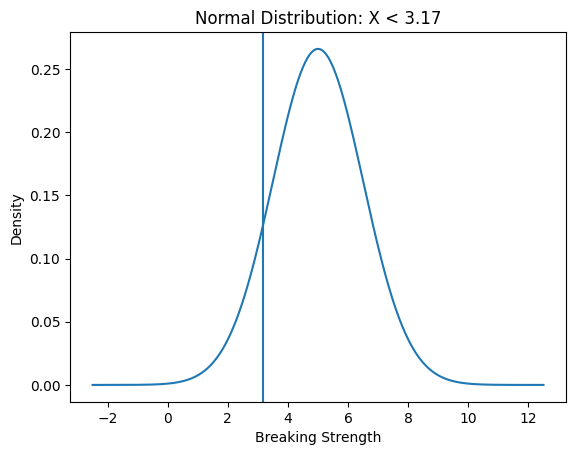

In [91]:
# Problem 2: Normal distribution calculations and visualizations

import math
import numpy as np
import matplotlib.pyplot as plt

# Parameters
mu = 5.0
sigma = 1.5

# Normal CDF using error function
def normal_cdf(x, mu, sigma):
    return 0.5 * (1 + math.erf((x - mu) / (sigma * math.sqrt(2))))

# Calculations
p_2_1 = normal_cdf(3.17, mu, sigma)                           # P(X < 3.17)
p_2_2 = 1 - normal_cdf(3.6, mu, sigma)                         # P(X >= 3.6)
p_2_3 = normal_cdf(5.5, mu, sigma) - normal_cdf(5.0, mu, sigma) # P(5 <= X <= 5.5)
p_2_4 = 1 - (normal_cdf(7.5, mu, sigma) - normal_cdf(3.0, mu, sigma)) # P(X not in [3, 7.5])

print("2.1 P(X < 3.17) =", p_2_1)

# Prepare x and normal pdf
x = np.linspace(mu - 5*sigma, mu + 5*sigma, 400)
pdf = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)

# Plot 2.1: X < 3.17
plt.figure()
plt.plot(x, pdf)
plt.axvline(3.17)
plt.title("Normal Distribution: X < 3.17")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()


2.2 P(X >= 3.6) = 0.8246760551477705


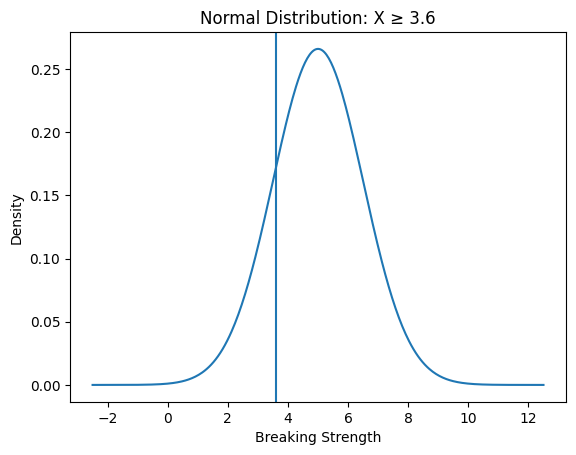

In [92]:
# Plot 2.2: X >= 3.6
print("2.2 P(X >= 3.6) =", p_2_2)
plt.figure()
plt.plot(x, pdf)
plt.axvline(3.6)
plt.title("Normal Distribution: X ≥ 3.6")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

2.3 P(5 <= X <= 5.5) = 0.13055865981823633


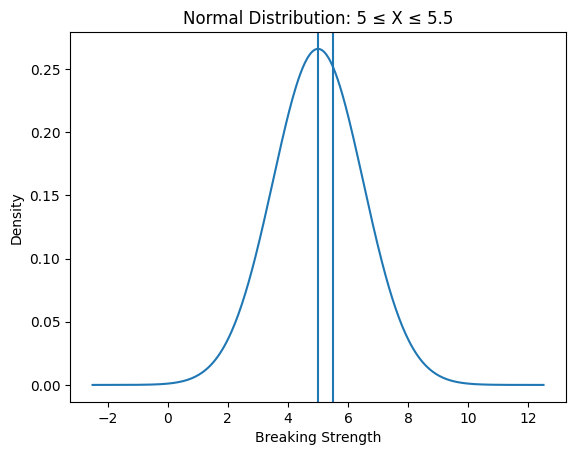

In [93]:
# Plot 2.3: 5 <= X <= 5.5
print("2.3 P(5 <= X <= 5.5) =", p_2_3)
plt.figure()
plt.plot(x, pdf)
plt.axvline(5.0)
plt.axvline(5.5)
plt.title("Normal Distribution: 5 ≤ X ≤ 5.5")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

2.4 P(X not in [3, 7.5]) = 0.13900157199868257


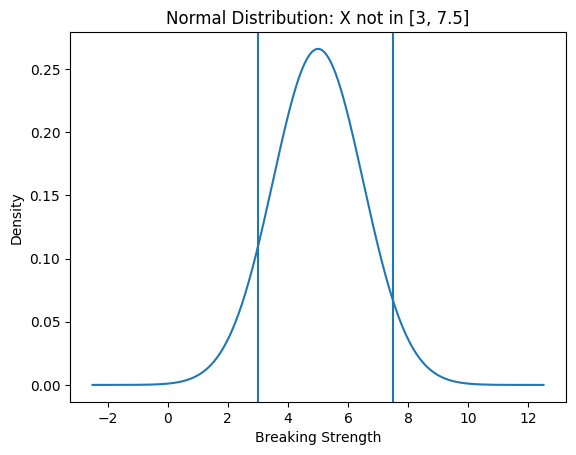

In [94]:
# Plot 2.4: X not in [3, 7.5]
print("2.4 P(X not in [3, 7.5]) =", p_2_4)
plt.figure()
plt.plot(x, pdf)
plt.axvline(3.0)
plt.axvline(7.5)
plt.title("Normal Distribution: X not in [3, 7.5]")
plt.xlabel("Breaking Strength")
plt.ylabel("Density")
plt.show()

**PROBLEM 3**

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df= pd.read_csv('/content/Zingaro_Company.csv')
df.shape

(75, 2)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unpolished            75 non-null     float64
 1   Treated and Polished  75 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB


n = 75
unpolished_mean = 134.11052653373332
std_unpolished = 33.0418044136061

Test for unpolished < 150
t-statistic = -4.164629601426757
one-sided p-value = 4.171286997419652e-05


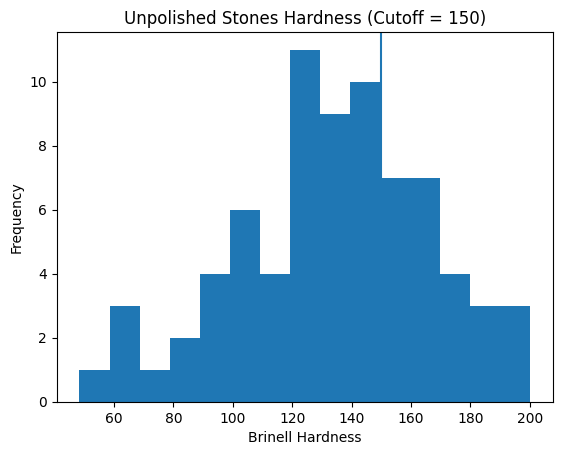

In [97]:

# Fix column names (in case of spaces)
df.columns = [c.strip() for c in df.columns]

unpolished = df["Unpolished"].dropna()
polished = df["Treated and Polished"].dropna()

# Given values (from your assignment)
n = len(unpolished)
unpolished_mean = unpolished.mean()
std_unpolished = unpolished.std(ddof=1)
optimum_mean = 150

print("n =", n)
print("unpolished_mean =", unpolished_mean)
print("std_unpolished =", std_unpolished)

# 3.1 One-sample t-test (H1: mean < 150)
t_stat, p_two_sided = stats.ttest_1samp(unpolished, popmean=150)
p_one_sided = p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2

print("\nTest for unpolished < 150")
print("t-statistic =", t_stat)
print("one-sided p-value =", p_one_sided)


# Plot 1: Unpolished distribution with cutoff 150
plt.figure()
plt.hist(unpolished, bins=15)
plt.axvline(150)
plt.title("Unpolished Stones Hardness (Cutoff = 150)")
plt.xlabel("Brinell Hardness")
plt.ylabel("Frequency")
plt.show()



Compare polished vs unpolished
t-statistic = 3.242232050141406
p-value = 0.001588379295584306


/tmp/ipython-input-3851105914.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([unpolished, polished], labels=["Unpolished", "Treated and Polished"])


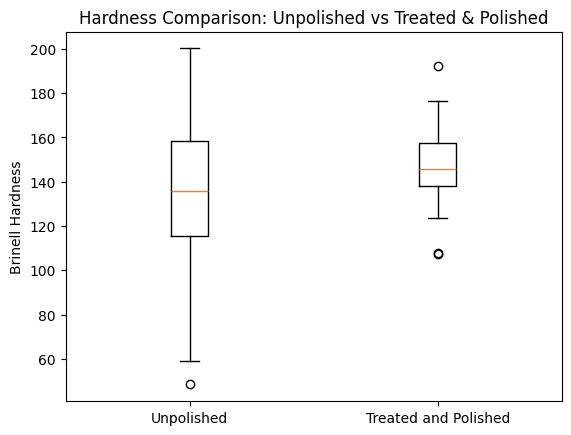

In [98]:
# 3.2 Two-sample t-test (compare means)
t_stat2, p_val2 = stats.ttest_ind(polished, unpolished, equal_var=False)

print("\nCompare polished vs unpolished")
print("t-statistic =", t_stat2)
print("p-value =", p_val2)
# Boxplot comparison
plt.figure()
plt.boxplot([unpolished, polished], labels=["Unpolished", "Treated and Polished"])
plt.title("Hardness Comparison: Unpolished vs Treated & Polished")
plt.ylabel("Brinell Hardness")
plt.show()

**PROBLEM 4**

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load data
df = pd.read_excel("/content/Dental Hardness data.xlsx")
df.columns = [c.strip() for c in df.columns]

In [100]:
df.shape

(90, 5)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Dentist   90 non-null     int64
 1   Method    90 non-null     int64
 2   Alloy     90 non-null     int64
 3   Temp      90 non-null     int64
 4   Response  90 non-null     int64
dtypes: int64(5)
memory usage: 3.6 KB


In [102]:
df.isnull().sum()

,0
Dentist,0
Method,0
Alloy,0
Temp,0
Response,0


In [103]:
df.head()

,Dentist,Method,Alloy,Temp,Response
0,1,1,1,1500,813
1,1,1,1,1600,792
2,1,1,1,1700,792
3,1,1,2,1500,907
4,1,1,2,1600,792


In [104]:
df.tail()

,Dentist,Method,Alloy,Temp,Response
85,5,3,1,1600,483
86,5,3,1,1700,405
87,5,3,2,1500,536
88,5,3,2,1600,405
89,5,3,2,1700,312



--- Alloy 1 ---
Shapiro-Wilk (per dentist):
Dentist 1: p = 0.3254693632188942
Dentist 2: p = 0.841544387628862
Dentist 3: p = 0.12953560483047716
Dentist 4: p = 0.05333654291277101
Dentist 5: p = 0.08127790851660108
Levene p-value = 0.2565537418543795
ANOVA p-value = 0.11656712140267628


/tmp/ipython-input-325767265.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=dentists)


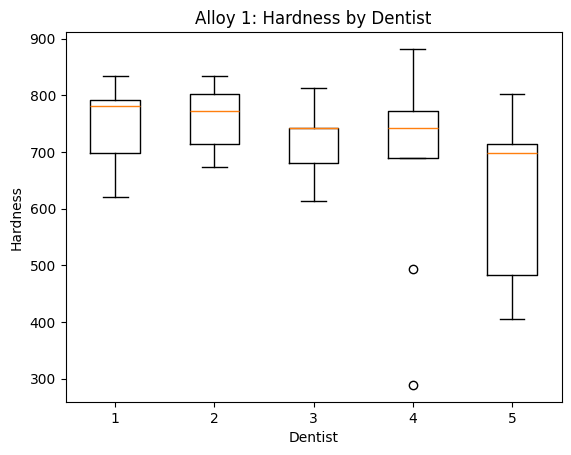


--- Alloy 2 ---
Shapiro-Wilk (per dentist):
Dentist 1: p = 0.27593872565209243
Dentist 2: p = 0.5735055333426523
Dentist 3: p = 0.5213087304159562
Dentist 4: p = 0.007332685121063265
Dentist 5: p = 0.33861078485472895
Levene p-value = 0.23686777576324952
ANOVA p-value = 0.7180309510793431


/tmp/ipython-input-325767265.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=dentists)


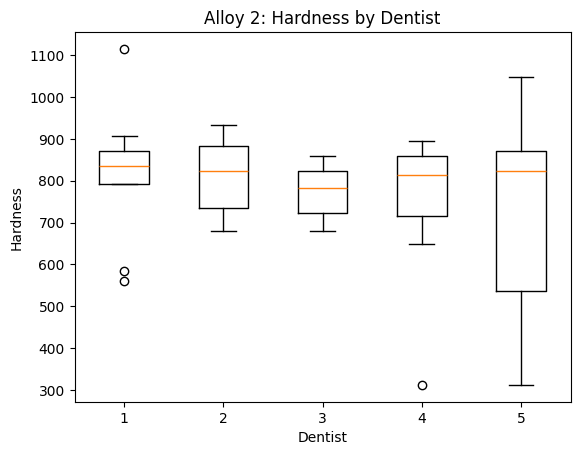

In [105]:

# 4.1 Effect of DENTIST (One-way ANOVA), separately for each Alloy

for alloy in sorted(df["Alloy"].unique()):
    print(f"\n--- Alloy {alloy} ---")
    sub = df[df["Alloy"] == alloy]

    dentists = sorted(sub["Dentist"].unique())
    groups = [sub[sub["Dentist"] == d]["Response"] for d in dentists]

    # Assumptions
    print("Shapiro-Wilk (per dentist):")
    for d in dentists:
        _, p = stats.shapiro(sub[sub["Dentist"] == d]["Response"])
        print(f"Dentist {d}: p = {p}")

    _, levene_p = stats.levene(*groups)
    print("Levene p-value =", levene_p)

    # ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    print("ANOVA p-value =", p_val)

    # Boxplot
    plt.figure()
    plt.boxplot(groups, labels=dentists)
    plt.title(f"Alloy {alloy}: Hardness by Dentist")
    plt.xlabel("Dentist")
    plt.ylabel("Hardness")
    plt.show()



--- Alloy 1 ---
Shapiro-Wilk (per method):
Method 1: p = 0.1819861143797435
Method 2: p = 0.9030333961962251
Method 3: p = 0.14254827970120204
Levene p-value = 0.0034160381460233966
ANOVA p-value = 0.0041634121675055424


/tmp/ipython-input-3010552248.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=methods)


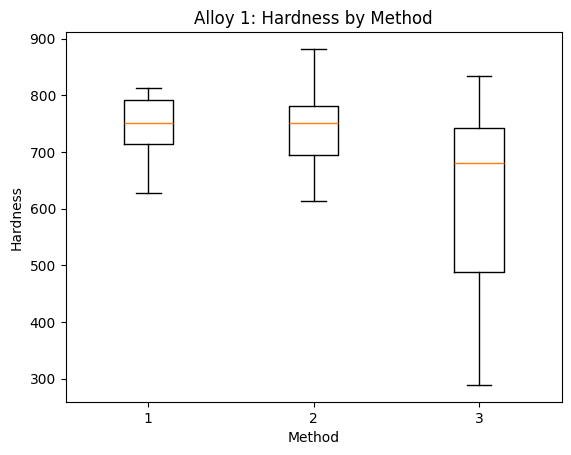

Tukey HSD:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
     1      2   -6.1333  0.987  -102.714  90.4473  False
     1      3    -124.8 0.0085 -221.3807 -28.2193   True
     2      3 -118.6667 0.0128 -215.2473  -22.086   True
--------------------------------------------------------

--- Alloy 2 ---
Shapiro-Wilk (per method):
Method 1: p = 0.758239031460697
Method 2: p = 0.001051113443000027
Method 3: p = 0.10259048044955665
Levene p-value = 0.044692699391586675
ANOVA p-value = 5.4158710514431865e-06


/tmp/ipython-input-3010552248.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=methods)


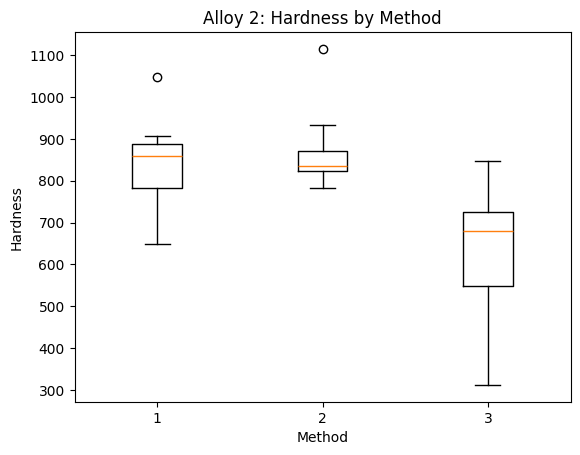

Tukey HSD:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2 meandiff p-adj    lower     upper   reject
--------------------------------------------------------
     1      2     27.0 0.8212  -82.4546  136.4546  False
     1      3   -208.8 0.0001 -318.2546  -99.3454   True
     2      3   -235.8    0.0 -345.2546 -126.3454   True
--------------------------------------------------------


In [106]:
# 4.2 Effect of METHOD (One-way ANOVA + Tukey), separately for each Alloy


for alloy in sorted(df["Alloy"].unique()):
    print(f"\n--- Alloy {alloy} ---")
    sub = df[df["Alloy"] == alloy]

    methods = sorted(sub["Method"].unique())
    groups = [sub[sub["Method"] == m]["Response"] for m in methods]

    # Assumptions
    print("Shapiro-Wilk (per method):")
    for m in methods:
        _, p = stats.shapiro(sub[sub["Method"] == m]["Response"])
        print(f"Method {m}: p = {p}")

    _, levene_p = stats.levene(*groups)
    print("Levene p-value =", levene_p)

    # ANOVA
    f_stat, p_val = stats.f_oneway(*groups)
    print("ANOVA p-value =", p_val)

    # Boxplot
    plt.figure()
    plt.boxplot(groups, labels=methods)
    plt.title(f"Alloy {alloy}: Hardness by Method")
    plt.xlabel("Method")
    plt.ylabel("Hardness")
    plt.show()

    # Tukey post-hoc
    print("Tukey HSD:")
    tukey = pairwise_tukeyhsd(endog=sub["Response"], groups=sub["Method"], alpha=0.05)
    print(tukey.summary())


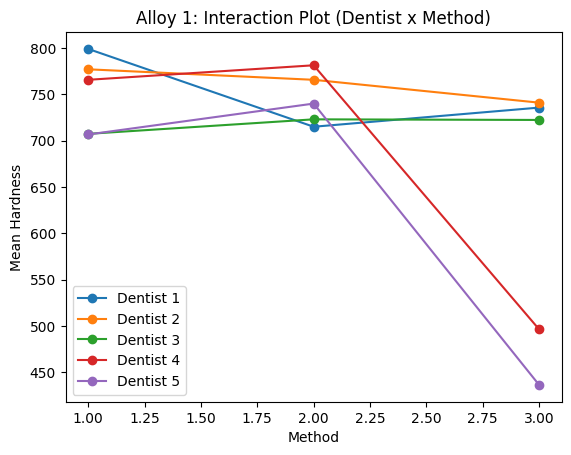

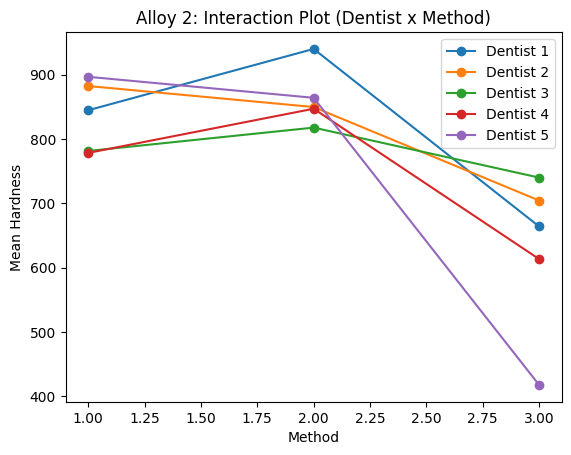

In [107]:
# 4.3 Interaction Plot (Dentist x Method), separately for each Alloy

for alloy in sorted(df["Alloy"].unique()):
    sub = df[df["Alloy"] == alloy]

    means = sub.groupby(["Dentist", "Method"])["Response"].mean().reset_index()

    plt.figure()
    for d in sorted(means["Dentist"].unique()):
        temp = means[means["Dentist"] == d]
        plt.plot(temp["Method"], temp["Response"], marker='o', label=f"Dentist {d}")

    plt.title(f"Alloy {alloy}: Interaction Plot (Dentist x Method)")
    plt.xlabel("Method")
    plt.ylabel("Mean Hardness")
    plt.legend()
    plt.show()


In [108]:
# 4.4 Two-way ANOVA (Dentist + Method + Interaction), separately for each Alloy
for alloy in sorted(df["Alloy"].unique()):
    print(f"\n--- Alloy {alloy} ---")
    sub = df[df["Alloy"] == alloy]

    model = ols("Response ~ C(Dentist) + C(Method) + C(Dentist):C(Method)", data=sub).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(anova_table)


--- Alloy 1 ---
                             sum_sq    df          F    PR(>F)
C(Dentist)            106683.688889   4.0   3.899638  0.011484
C(Method)             148472.177778   2.0  10.854287  0.000284
C(Dentist):C(Method)  185941.377778   8.0   3.398383  0.006793
Residual              205180.000000  30.0        NaN       NaN

--- Alloy 2 ---
                             sum_sq    df          F    PR(>F)
C(Dentist)             56797.911111   4.0   1.106152  0.371833
C(Method)             499640.400000   2.0  19.461218  0.000004
C(Dentist):C(Method)  197459.822222   8.0   1.922787  0.093234
Residual              385104.666667  30.0        NaN       NaN
